# Tentative

In [18]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_noise import *
import pickle
import copy
import time
import humanfriendly
from skimage.restoration import estimate_sigma
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import random
import humanfriendly

device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

mps
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load 20 frame aligned dataset

In [19]:
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile = pickle.load(file)

tile.apply("crop", parameters = {"crop_idx": (slice(50,tile.EDX_dim[0]-50),slice(50,tile.EDX_dim[1]-50),slice(None,None,None))})
#tile.apply("binning", parameters={"dim": (974,974,250)})
#tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})

tile.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None


### Load 100 frame aligned set

In [20]:
with open('../preprocessing_basic/results/preprocessed_edx/20260114_062341_tile_aligned_100frames_align2zero.pkl', 'rb') as file:
    tile_ref = pickle.load(file)

tile_ref.apply("crop", parameters = {"crop_idx": (slice(50,tile_ref.EDX_dim[0]-50),slice(50,tile_ref.EDX_dim[1]-50),slice(None,None,None))})
#tile_ref.apply("binning", parameters={"dim": (int(tile_ref.EDX_dim[0]/2),int(tile_ref.EDX_dim[1]/2),250)})
#tile_ref.apply("MeanFilterEDX", parameters={"kernel_size": 3})

#h, w, b = tile.EDX_dim
tile_ref.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_path=tmp/unaligned_hsi_100frames, al...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None


### Additional cropping

In [21]:
tile.apply("crop", parameters = {"crop_idx": (slice(0,500),slice(0,500),slice(None,None,None))})
tile_ref.apply("crop", parameters = {"crop_idx": (slice(0,500),slice(0,500),slice(None,None,None))})

<EM_EDX | 5 steps logged>

### Basic hyperspy

In [ ]:
!pip install numexpr

In [ ]:
# Step 1: Background removal

# 1a. Wrap raw cube
s = hs.signals.Signal1D(tile_ref.EDX)

# 1b. Define axes
s.axes_manager.signal_axes[0].name = "Energy"
s.axes_manager.signal_axes[0].units = "keV"
s.axes_manager.signal_axes[0].axis = tile_ref.xray_energies
s.axes_manager.navigation_axes[0].name = "y"
s.axes_manager.navigation_axes[1].name = "x"

# 1c. Promote to EDS_TEM
s.set_signal_type("EDS_TEM")
s.set_microscope_parameters(beam_energy=80)

# 1d. Background model & fit
bg_model = s.create_model()
bg_model.multifit()

# 1e. Subtract background
s_bg_removed = s - bg_model.as_signal()

# 1f. Extract NumPy array of background-removed cube
EDX_bg_removed = s_bg_removed.data



In [ ]:
# Step 2: Peak fitting
import logging

# Suppress Hyperspy model warnings
logging.getLogger('hyperspy.model').setLevel(logging.ERROR)

# 2a. Define the peaks you care about
elements = ['C','N','O','P','S','Cl','Ca','Cu','Al','Fe','Os','Nd']

s_bg_removed.add_elements(elements)

# 2b. Create model including background + peaks
fit_model = s_bg_removed.create_model()

# 2c. Fit model across all pixels
fit_model.multifit()

# 2d. Reconstruct full cube of fitted spectra
s_fitted = fit_model.as_signal()

# 2e. Extract NumPy array for downstream use
EDX_fitted = s_fitted.data


In [9]:
tile_bg_rmv = tile_ref.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(None))},copy_instance=True)
tile_bg_rmv.EDX = EDX_bg_removed

#tile_fitted = tile_ref.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(None))},copy_instance=True)
#tile_fitted.EDX = EDX_fitted

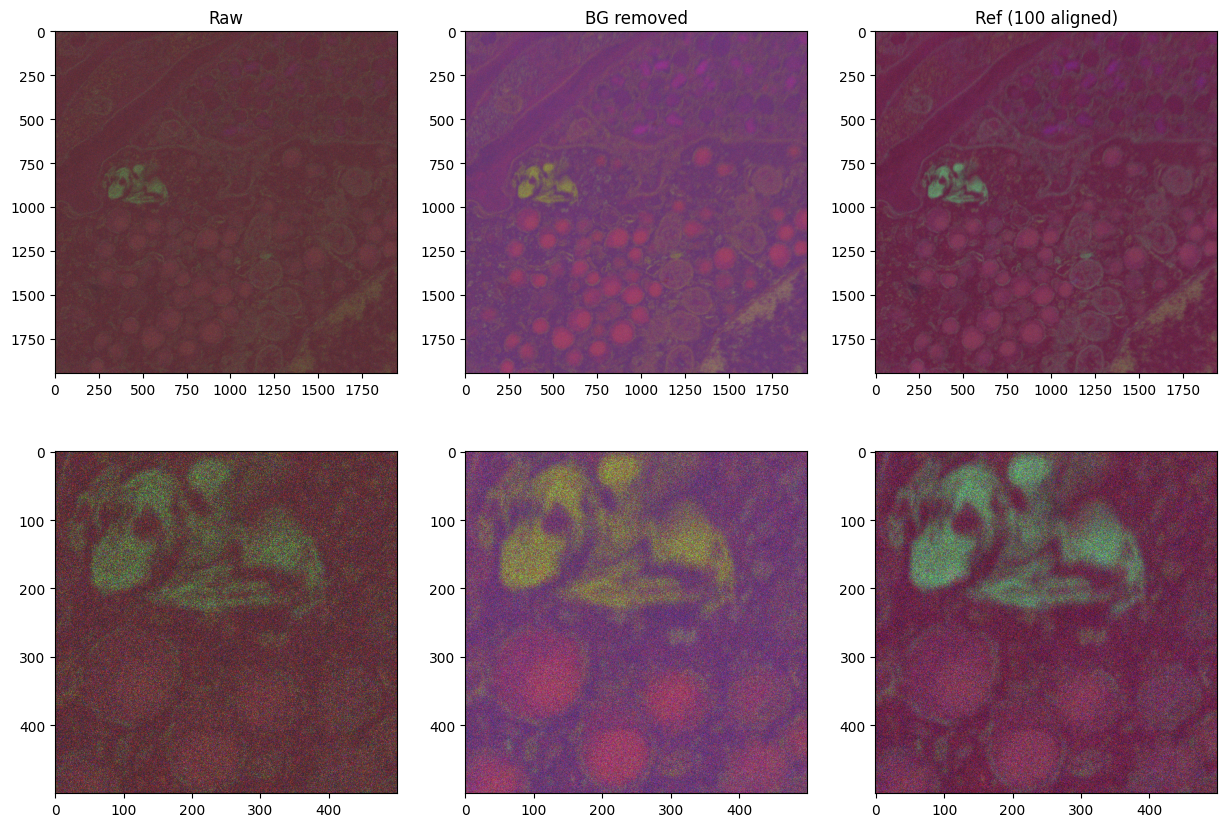

In [17]:
# compare
corr = 0


bands = [4,25,28]
zoom = (slice(750,1250),slice(250,750),slice(None))

f, ax = plt.subplots(2,3,figsize=(15,10))
ax[0][0].imshow(tile.FalseColor(bands))
ax[0][0].set_title('Raw')
ax[0][1].imshow(tile_bg_rmv.FalseColor(bands))
ax[0][1].set_title('BG removed')
ax[0][2].imshow(tile_ref.FalseColor(bands))
ax[0][2].set_title('Ref (100 aligned)')

ax[1][0].imshow(tile.FalseColor(bands)[zoom])
ax[1][1].imshow(tile_bg_rmv.FalseColor(bands)[zoom])
ax[1][2].imshow(tile_ref.FalseColor(bands)[zoom])

In [ ]:
print(tile.xray_energies[:10])
print(tile.xray_energies[-10:])

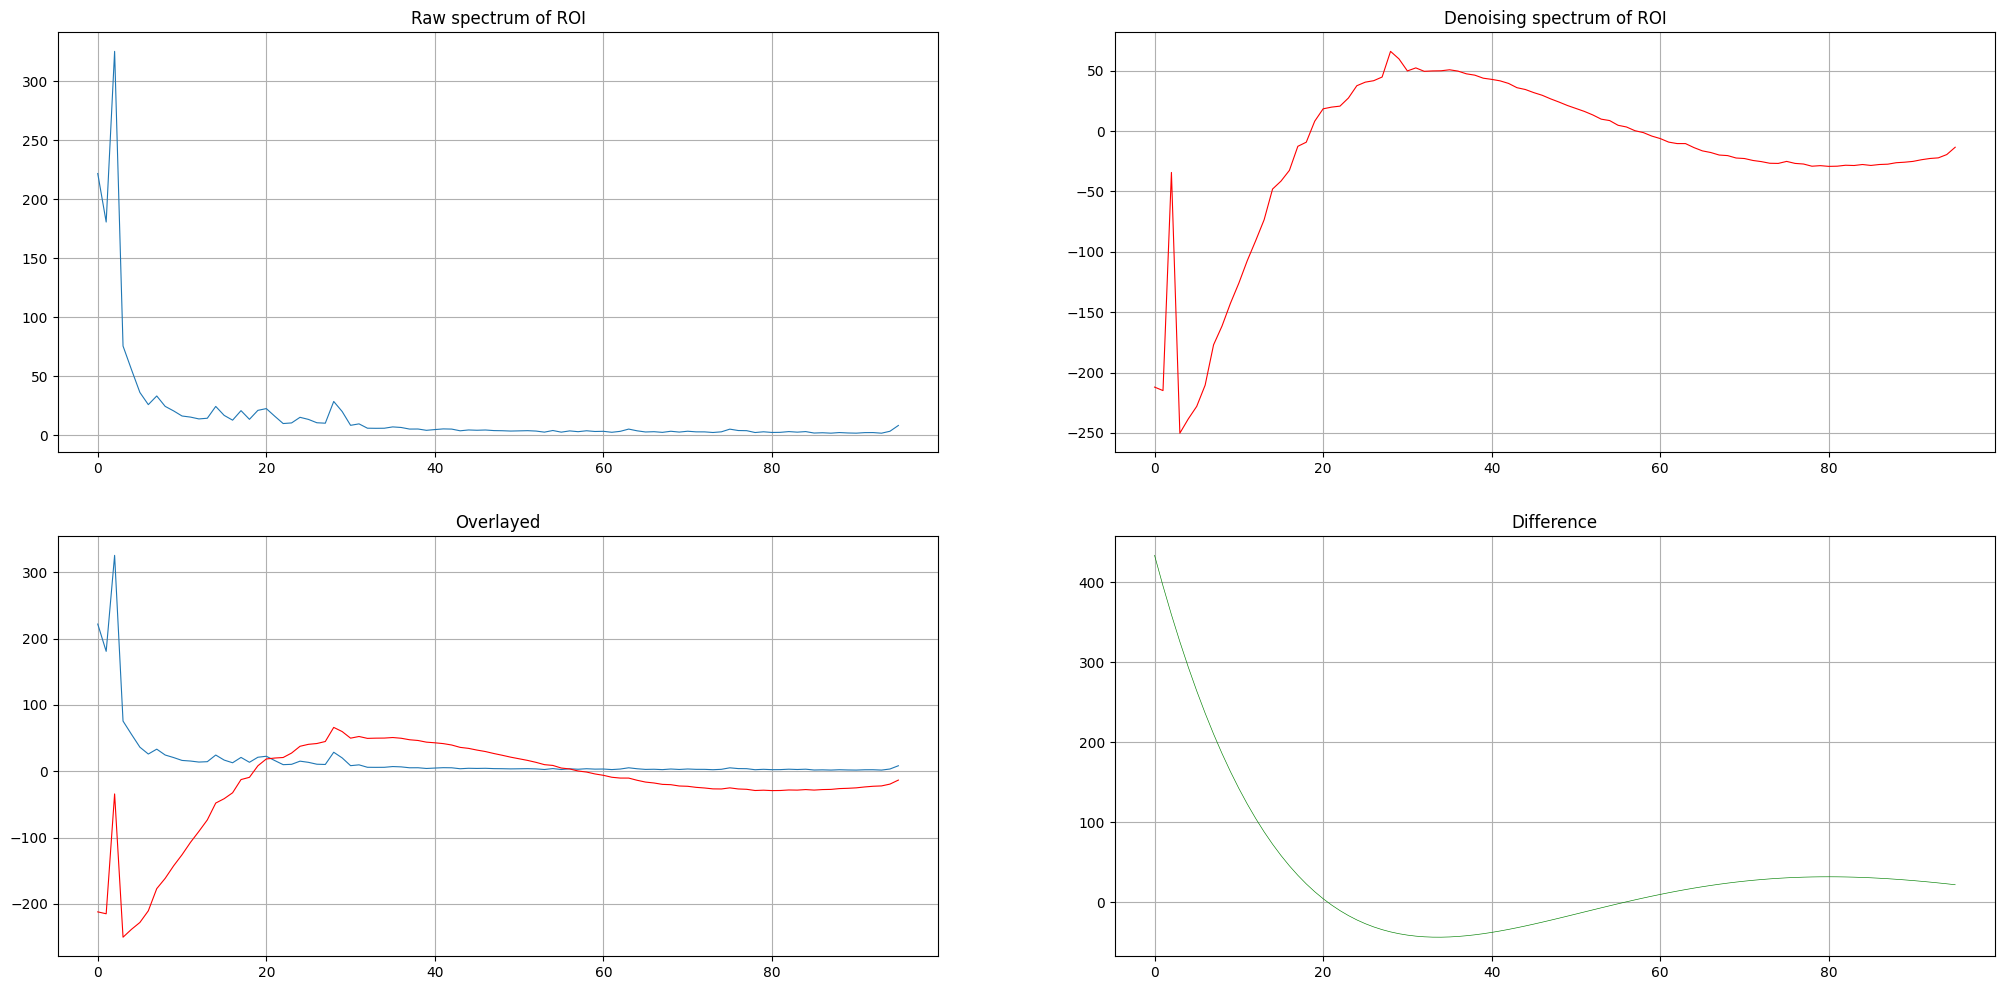

In [13]:
cutoff1 = 4
cutoff2 = 100
spec_data = tile_ref.EDX[210:220, 210:220, cutoff1:cutoff2]
spec_clean = tile_bg_rmv.EDX[210:220, 210:220, cutoff1:cutoff2]
lw = 0.8


f, ax = plt.subplots(2,2, figsize = (25,12))
ax[0][0].plot(np.sum(spec_data,axis=(0,1)),lw=lw)
ax[0][0].set_title('Raw spectrum of ROI')
ax[0][1].plot(np.sum(spec_clean,axis=(0,1)),'r',lw=lw)
ax[0][1].set_title('Denoising spectrum of ROI')

ax[1][0].plot(np.sum(spec_data,axis=(0,1)),lw=lw)
ax[1][0].plot(np.sum(spec_clean,axis=(0,1)),'r',lw=lw)
ax[1][0].set_title('Overlayed')


ax[1][1].plot((np.sum(spec_data,axis=(0,1)) - np.sum(spec_clean,axis=(0,1))),'g',lw=0.45)
ax[1][1].set_title('Difference')

for i in range(2):
    for j in range(2):
        ax[i][j].grid('ON')